In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
df = pd.read_excel("C:/Users/Admin/Desktop/Sharvari/Internship/Thiranex/Task 3/sample_-_superstore.xlsx")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Data Preprocessing

In [5]:
# Convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort values
df = df.sort_values('Order Date')

# Check nulls
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


# Create Time Series

In [6]:
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()
print(monthly_sales.head())

Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_16052\1992899268.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


# Plot Sales Trend

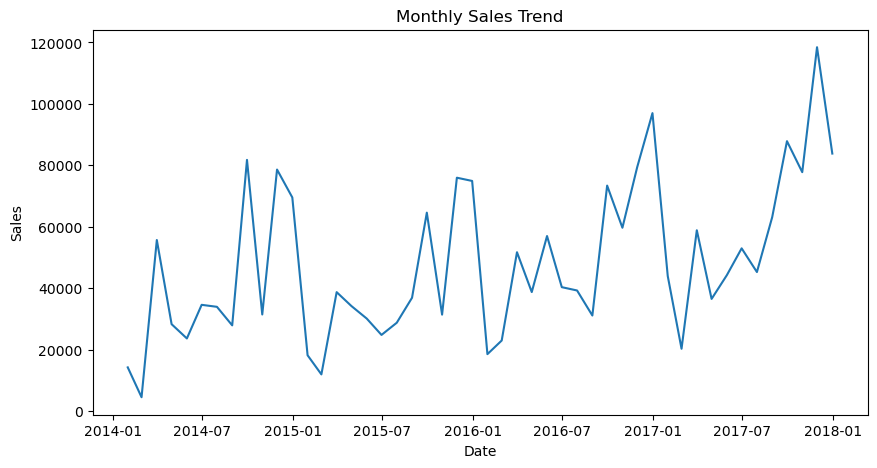

In [7]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Train-Test Split

In [8]:
train_size = int(len(monthly_sales) * 0.8)
train = monthly_sales[:train_size]
test = monthly_sales[train_size:]

# Build ARIMA Model

In [9]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   38
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -425.517
Date:                Sat, 25 Apr 2026   AIC                            857.035
Time:                        17:58:32   BIC                            861.867
Sample:                    01-31-2014   HQIC                           858.738
                         - 02-28-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2100      0.310      0.677      0.499      -0.398       0.818
ma.L1         -0.8966      0.145     -6.173      0.000      -1.181      -0.612
sigma2      6.531e+08   7.45e-11   8.77e+18      0.0

# Make Predictions

In [10]:
predictions = model_fit.forecast(steps=len(test))

# Evaluate Model

In [11]:
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 22608.93017187995
RMSE: 30116.618598417896


# Plot Actual vs Predicted

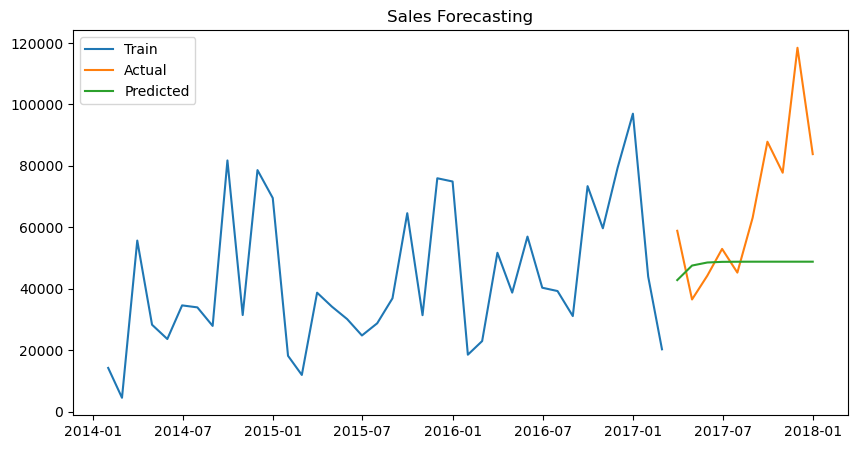

In [12]:
plt.figure(figsize=(10,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions, label='Predicted')
plt.legend()
plt.title("Sales Forecasting")
plt.show()

# Forecast Future (Next 6 Months)

In [13]:
future_forecast = model_fit.forecast(steps=6)
print(future_forecast)

2017-03-31    42829.374977
2017-04-30    47560.573570
2017-05-31    48554.181530
2017-06-30    48762.851015
2017-07-31    48806.674088
2017-08-31    48815.877454
Freq: ME, Name: predicted_mean, dtype: float64


# Plot Future Forecast

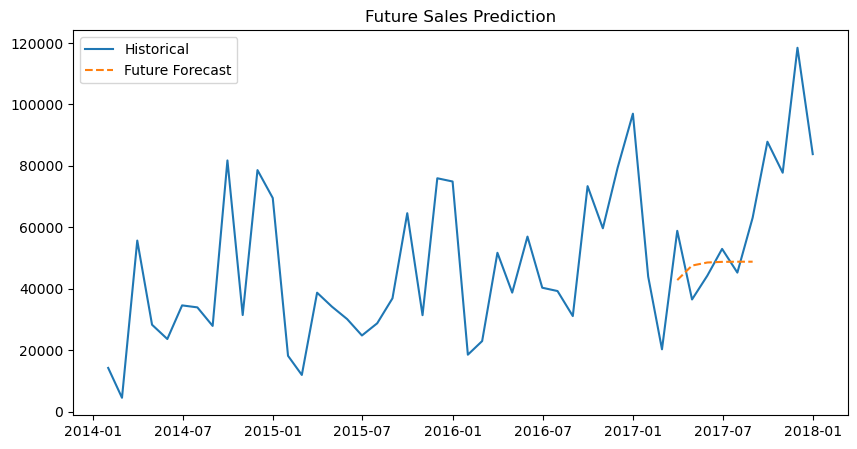

In [14]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales, label='Historical')
plt.plot(future_forecast, label='Future Forecast', linestyle='dashed')
plt.legend()
plt.title("Future Sales Prediction")
plt.show()